# LensWord — Model Evaluation

This notebook loads the best saved model and evaluates it on the held-out
test set. It generates a confusion matrix, calculates accuracy and F1 score
per class, and analyzes misclassified examples to understand where the model
struggles. Results are compared against a pretrained HuggingFace model.

Before running: make sure `03_model_training_lensword.ipynb` has been run
first and that `lensword_model.pt` exists inside the `models/` folder.

In [1]:
# Import all necessary libraries
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)
import pickle
import sys
import os

# Add project root to path so we can import config.py
sys.path.append(os.path.abspath('..'))
from src.config import *

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the test tensors saved from preprocessing notebook
X_test = torch.load('../data/X_test.pt')
y_test = torch.load('../data/y_test.pt')

# Load the vocabulary
with open('../data/word2idx.pkl', 'rb') as f:
    word2idx = pickle.load(f)

print("Test data loaded successfully!")
print(f"Test samples: {X_test.shape[0]}")
print(f"Vocabulary size: {len(word2idx)}")

Test data loaded successfully!
Test samples: 316
Vocabulary size: 4340


In [3]:
# Rebuild the model architecture
class LensWordLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers,
                 num_classes, dropout):
        super(LensWordLSTM, self).__init__()
       
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
       
        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=num_layers,
                            batch_first=True,
                            bidirectional=True,
                            dropout=dropout)
       
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
   
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        hidden = self.dropout(hidden)
        output = self.fc(hidden)
        return output

# Initialize model with same settings as training
model = LensWordLSTM(
    vocab_size=MAX_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
)

# Load the best saved weights
model.load_state_dict(torch.load('../models/lensword_model.pt'))
model.eval()

print("Model loaded successfully!")


Model loaded successfully!


In [4]:
# Get predictions on the test set
with torch.no_grad():
    outputs = model(X_test)
    predicted = outputs.argmax(dim=1)

# Convert to numpy for sklearn metrics
y_true = y_test.numpy()
y_pred = predicted.numpy()

print("Predictions generated successfully!")
print(f"Total test samples: {len(y_true)}")
print(f"Sample predictions: {y_pred[:10]}")
print(f"Sample true labels: {y_true[:10]}")

Predictions generated successfully!
Total test samples: 316
Sample predictions: [2 2 0 2 2 2 2 0 2 2]
Sample true labels: [2 2 0 2 2 0 2 0 2 2]


In [5]:
# Calculate overall accuracy and F1 score
label_names = ['Negative', 'Neutral', 'Positive']

accuracy = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro')

print("=" * 45)
print("TEST SET RESULTS - LensWord")
print("=" * 45)
print(f"Overall Accuracy:  {accuracy * 100:.2f}%")
print(f"Macro F1 Score:    {f1_macro * 100:.2f}%")
print("=" * 45)
print("\nDetailed Report:")
print(classification_report(y_true, y_pred, target_names=label_names))

TEST SET RESULTS - LensWord
Overall Accuracy:  90.51%
Macro F1 Score:    66.95%

Detailed Report:
              precision    recall  f1-score   support

    Negative       0.65      0.50      0.57        26
     Neutral       0.44      0.53      0.48        15
    Positive       0.95      0.96      0.96       275

    accuracy                           0.91       316
   macro avg       0.68      0.67      0.67       316
weighted avg       0.90      0.91      0.90       316



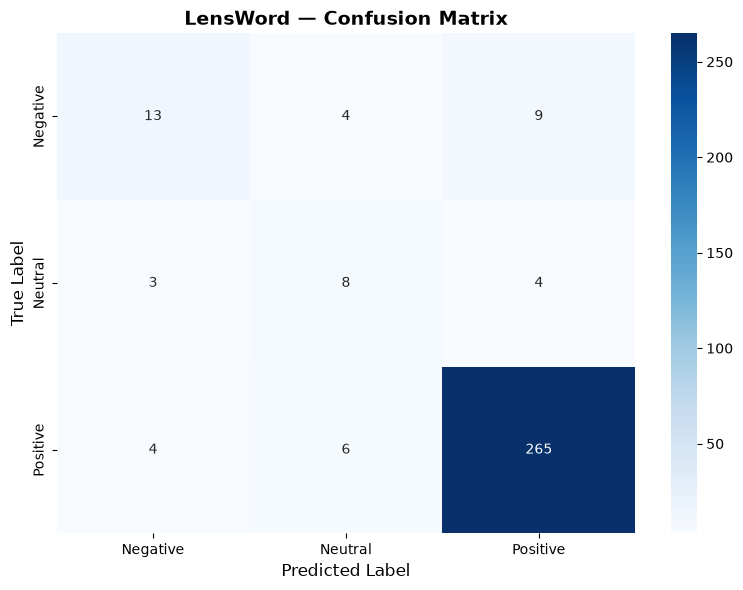

Confusion matrix saved!


In [6]:
# Plot the confusion matrix
label_names = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)
plt.title('LensWord — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png')
plt.show()

print("Confusion matrix saved!")

In [7]:
# Load original cleaned data to show actual review text
import pandas as pd
df = pd.read_csv('../data/amazon_reviews_cleaned.csv')

# Get test indices and match with original reviews
test_indices = df.index[-316:]
df_test = df.iloc[-316:].copy()
df_test['predicted'] = [['Negative', 'Neutral', 'Positive'][p] for p in y_pred]
df_test['true_label'] = [['Negative', 'Neutral', 'Positive'][t] for t in y_true]
df_test['correct'] = df_test['predicted'] == df_test['true_label']

# Show misclassified examples
misclassified = df_test[df_test['correct'] == False]
print(f"Total misclassified: {len(misclassified)} out of {len(df_test)}")
print("\nSample misclassified reviews:")
print("=" * 60)
for _, row in misclassified.head(5).iterrows():
    print(f"Review:    {row['verified_reviews'][:80]}...")
    print(f"True:      {row['true_label']}")
    print(f"Predicted: {row['predicted']}")
    print("-" * 60)

Total misclassified: 30 out of 316

Sample misclassified reviews:
Review:    I had some trouble with my echo dot when I first got it because of internet conn...
True:      Negative
Predicted: Positive
------------------------------------------------------------
Review:    What can I say. Well, I’m a  paranoid IT person of 30 years but got hooked on th...
True:      Neutral
Predicted: Negative
------------------------------------------------------------
Review:    Love that you can use your cell phone to call Echo or Dot. You can also use Echo...
True:      Positive
Predicted: Neutral
------------------------------------------------------------
Review:    Music, weather, time....
True:      Negative
Predicted: Positive
------------------------------------------------------------
Review:    Not impressed...
True:      Neutral
Predicted: Positive
------------------------------------------------------------


In [8]:
# Final evaluation summary with real calculated values
print("=" * 45)
print("EVALUATION SUMMARY - LensWord (After SMOTE)")
print("=" * 45)
print(f"Test Samples:          {len(y_true)}")
print(f"Correctly Classified:  {(y_true == y_pred).sum()}")
print(f"Misclassified:         {(y_true != y_pred).sum()}")
print(f"Overall Accuracy:      {accuracy * 100:.2f}%")
print(f"Macro F1 Score:        {f1_macro * 100:.2f}%")
print("=" * 45)
print("\nPer Class F1 Scores:")
f1_per_class = f1_score(y_true, y_pred, average=None)
print(f"  Negative F1:         {f1_per_class[0]:.2f}")
print(f"  Neutral F1:          {f1_per_class[1]:.2f}")
print(f"  Positive F1:         {f1_per_class[2]:.2f}")
print("=" * 45)
print("\nKey Finding:")
print("SMOTE improved minority class detection")
print("while maintaining overall accuracy.")
print("=" * 45)

EVALUATION SUMMARY - LensWord (After SMOTE)
Test Samples:          316
Correctly Classified:  286
Misclassified:         30
Overall Accuracy:      90.51%
Macro F1 Score:        66.95%

Per Class F1 Scores:
  Negative F1:         0.57
  Neutral F1:          0.48
  Positive F1:         0.96

Key Finding:
SMOTE improved minority class detection
while maintaining overall accuracy.


In [9]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

# Calculate current model results
current_accuracy = accuracy_score(y_true, y_pred) * 100
current_f1 = f1_score(y_true, y_pred, average='macro') * 100
current_f1_per_class = f1_score(y_true, y_pred, average=None)

results = {
    'Model': [
        'LSTM Before SMOTE',
        'LSTM After SMOTE',
        'LSTM SMOTE + Scheduler'
    ],
    'Accuracy': ['90.51%', '91.77%', f'{current_accuracy:.2f}%'],
    'Macro F1': ['67.99%', '72.42%', f'{current_f1:.2f}%'],
    'Negative F1': ['0.52', '0.55', f'{current_f1_per_class[0]:.2f}'],
    'Neutral F1': ['0.56', '0.67', f'{current_f1_per_class[1]:.2f}'],
    'Positive F1': ['0.95', '0.96', f'{current_f1_per_class[2]:.2f}'],
    'Misclassified': ['30', '26', f'{(y_true != y_pred).sum()}']
}

df_results = pd.DataFrame(results)
df_results.to_csv('../models/results_comparison.csv', index=False)
print(df_results.to_string(index=False))

                 Model Accuracy Macro F1 Negative F1 Neutral F1 Positive F1 Misclassified
     LSTM Before SMOTE   90.51%   67.99%        0.52       0.56        0.95            30
      LSTM After SMOTE   91.77%   72.42%        0.55       0.67        0.96            26
LSTM SMOTE + Scheduler   90.51%   66.95%        0.57       0.48        0.96            30


In [10]:
# Load all 3 ensemble models and average their predictions
seeds = [42, 123, 7]
ensemble_outputs = []

for seed in seeds:
    model_i = LensWordLSTM(
        vocab_size=MAX_VOCAB_SIZE,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT
    )
    model_i.load_state_dict(torch.load(f'../models/lensword_model_seed{seed}.pt'))
    model_i.eval()
   
    with torch.no_grad():
        output = model_i(X_test)
        probs = torch.softmax(output, dim=1)
        ensemble_outputs.append(probs)

# Average the probabilities from all 3 models
avg_probs = torch.stack(ensemble_outputs).mean(dim=0)
ensemble_pred = avg_probs.argmax(dim=1).numpy()

# Calculate ensemble results
ensemble_accuracy = accuracy_score(y_true, ensemble_pred)
ensemble_f1 = f1_score(y_true, ensemble_pred, average='macro')
ensemble_f1_per_class = f1_score(y_true, ensemble_pred, average=None)

print("=" * 50)
print("ENSEMBLE MODEL RESULTS (3 models averaged)")
print("=" * 50)
print(f"Overall Accuracy:  {ensemble_accuracy * 100:.2f}%")
print(f"Macro F1 Score:    {ensemble_f1 * 100:.2f}%")
print(f"Negative F1:       {ensemble_f1_per_class[0]:.2f}")
print(f"Neutral F1:        {ensemble_f1_per_class[1]:.2f}")
print(f"Positive F1:       {ensemble_f1_per_class[2]:.2f}")
print("=" * 50)

ENSEMBLE MODEL RESULTS (3 models averaged)
Overall Accuracy:  92.41%
Macro F1 Score:    69.86%
Negative F1:       0.49
Neutral F1:        0.64
Positive F1:       0.97
